In [13]:
import logging

import numpy as np
import pandas as pd
from matplotlib.path import Path
from mphsweepkit.meta_tex import *
from mphsweepkit.process_data import DataPlot, PlotSettings, PlotTextOverrides

from dimensional_performance_factor.meta import paths

# Logging
logging.basicConfig(format='%(levelname)s:%(message)s', level=logging.WARNING)

# for scaling: 
cm = 1 / 2.54

# rectangle marker for legend
a = 1.0
b = 2 * a
verts = np.array([
    [-a/2, -b/2],
    [ a/2, -b/2],
    [ a/2,  b/2],
    [-a/2,  b/2],
    [-a/2, -b/2],
])
rect_marker = Path(verts)

# Paths:
material_path = paths.material_data
simulation_path = paths.simulation_data
plot_path = paths.grafics
measurements_path = paths.measurement_data

In [14]:
dp = DataPlot.from_result_folder(simulation_path.joinpath("global_data")  )
# dp.combined_df

#### Simulation CYLINDER vs CUBOID

In [15]:
def plot_geometry_ratio(dp: DataPlot, ax, qty="p (core)"):
    
    custom_settings = PlotSettings(
        x_scale="linear",
        y_scale="linear",
        show_grid=True,
        grid_which="both",
        grid_alpha=0.5,
        marker_styles=(" ",),
        line_width=2.2,
        color_map_name="viridis",
        line_styles=("-", "--", "-.", ":"),
        show_color_legend=True,
        show_style_legend=True,
        use_tight_layout=True,
        show_title=False
    )

    dp.ratio_plot(
        ax,
        y_col=qty,
        x_col="freq",
        split_col="cut_switch",
        numerator_value="1.0",
        denominator_value="2.0",
        style_col="matsw.comp1.sw1_name",
        color_col="core_temperature",
        settings=custom_settings,
        text_overrides=PlotTextOverrides(
            x_label="Frequency",
            x_unit="kHz",
            y_label=r"$P_\mathrm{core,cylinder} / P_\mathrm{core,cuboid}$",
            y_unit="",
            color_label=r"$T_\mathrm{core}$",
            color_unit="C",
            style_label="material type",
            style_unit=" ",
    ),
)
plt.show()

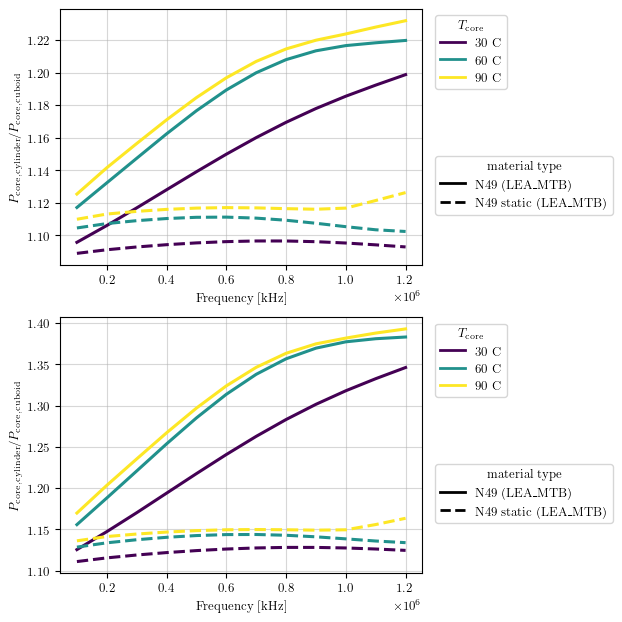

In [16]:
fig, ax = plt.subplots(2, figsize=(16*cm, 16*cm))
plot_geometry_ratio(dp, ax[0], qty="p (core)")
plot_geometry_ratio(dp, ax[1], qty="p (cut)")
# plot_geometry_ratio(dp, ax[1], qty="p_el (cut)")

#### Comparison with the measurements

Select the material model to be used:

In [17]:
# dp.combined_df = dp.combined_df[dp.combined_df["matsw.comp1.sw1_name"] == "N49 static (LEA_MTB)"]
dp.combined_df = dp.combined_df[dp.combined_df["matsw.comp1.sw1_name"] != "N49 static (LEA_MTB)"]

In [18]:
def plot_geometry_comparison(dp: DataPlot, ax, qty="p (core)"):
    
    custom_settings = PlotSettings(
        x_scale="linear",
        y_scale="linear",
        show_grid=True,
        grid_which="both",
        grid_alpha=0.5,
        marker_styles=(" ",),
        line_width=2.2,
        color_map_name="viridis",
        line_styles=("-", "--", "-.", ":"),
        show_color_legend=True,
        show_style_legend=True,
        use_tight_layout=True,
        show_title=False
    )

    dp.y_over_x_with_color_and_style(
        ax,
        y_col=qty,
        x_col="freq",
        color_col="core_temperature",
        style_col="cut_switch",
        settings=custom_settings,
        text_overrides=PlotTextOverrides(
            x_label="Frequency",
            x_unit="kHz",
            y_label=qty,
            y_unit=r"W",
            color_label=r"$T_\mathrm{core}$",
            color_unit="C",
            style_label="Cyl vs Cuboid",
            style_unit=" "
        )
    )

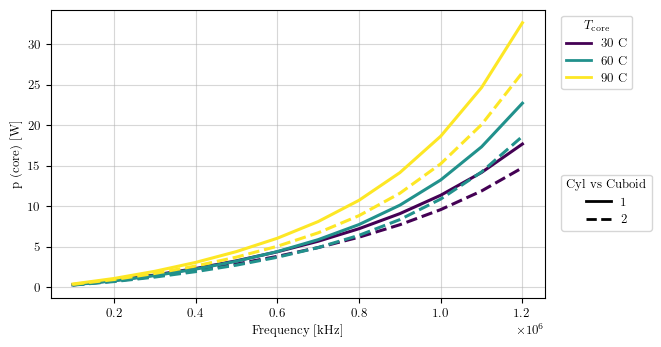

In [19]:
fig, ax = plt.subplots(figsize=(17 / 2.54, 9 / 2.54))  
plot_geometry_comparison(dp=dp, ax=ax, qty="p (core)")

#### Simulation vs Measurements

Load the measurements and add overall losses

In [20]:
df_meas = pd.read_csv(measurements_path.joinpath("fd_results.csv"), sep=",", decimal=".", index_col=None)
df_meas["p_total"] = df_meas["volume"] * df_meas["p_density_hyst"]
# df_meas

Filter the simulaion data

In [21]:
# dp.combined_df = dp.combined_df[dp.combined_df["core_temperature"] == "30.0"]
dp.combined_df = dp.combined_df[dp.combined_df["core_temperature"] == "60.0"]
# dp.combined_df = dp.combined_df[dp.combined_df["core_temperature"] == "90.0"]
# dp.combined_df = dp.combined_df[dp.combined_df["core_temperature"] != "90.0"]

dp.combined_df = dp.combined_df[dp.combined_df["freq"].astype(float) >= 201_000]

# dp.combined_df

In [22]:
def apply_cut_type_legend_mapping(ax):
    label_map = {
        "1": "cylinder",
        "2": "cuboid",
        "1.0": "cylinder",
        "2.0": "cuboid",
    }

    handles, labels = ax.get_legend_handles_labels()
    mapped_labels = [label_map.get(lbl.strip(), lbl) for lbl in labels]

    # remove duplicates while preserving order
    seen = set()
    unique_handles, unique_labels = [], []
    for h, l in zip(handles, mapped_labels):
        if l not in seen:
            seen.add(l)
            unique_handles.append(h)
            unique_labels.append(l)

    ax.legend(unique_handles, unique_labels)

def plot_meas_vs_sim(dp: DataPlot, ax, qty="p (core)"):
    
    custom_settings = PlotSettings(
        x_scale="linear",
        y_scale="linear",
        show_grid=True,
        grid_which="both",
        grid_alpha=0.5,
        marker_styles=("o", rect_marker),
        line_width=2.2,
        color_map_name="viridis",
        line_styles=("-", ":"),
        show_color_legend=True,
        show_style_legend=True,
        use_tight_layout=True,
        show_title=False
    )

    dp.y_over_x_with_color_and_style(
        ax,
        y_col=qty,
        x_col="freq",
        color_col="core_temperature",
        style_col="cut_switch",
        settings=custom_settings,
        text_overrides=PlotTextOverrides(
            x_label="Frequency",
            x_unit="kHz",
            y_label="Total Core Losses",
            y_unit=r"W",
            color_label=r"$T_\mathrm{core}$",
            color_unit="C",
            style_label="CUT choice",
            style_unit=" "
        )
    )

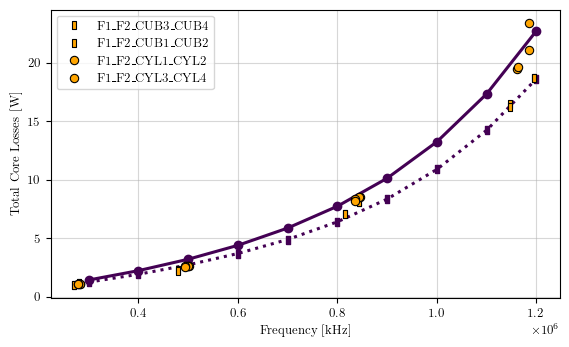

In [24]:
fig, ax = plt.subplots(figsize=(17 / 2.54, 9 / 2.54))  
# dp.combined_df = dp.combined_df[dp.combined_df["freq"].astype(float) >= 201_000_000]
plot_meas_vs_sim(dp=dp, ax=ax, qty="p (core)")


# Measurement groups
# ranges correspond to the rows in the measurement data file
# 30 °C, 60 °C
measurement_groups = [
#     {
#         "F1_F2_CUB3_CUB4": {
#             "ranges": [(2, 5), (30, 33)],
#             "linestyle": ":",
#             "color": "blue",
#         },
#         "F1_F2_CUB1_CUB2": {
#             "ranges": [(6, 9), (10, 13)],
#             "linestyle": ":",
#             "color": "blue",
#         },
#         "F1_F2_CYL1_CYL2": {
#             "ranges": [(14, 17), (18, 21)],
#             "linestyle": "-",
#             "color": "blue",
#         },
#         "F1_F2_CYL3_CYL4": {
#             "ranges": [(22, 25), (26, 29)],
#             "linestyle": "-",
#             "color": "blue",
#         },
#     },
    {
        "F1_F2_CUB3_CUB4": {
            "ranges": [(34, 37), (38, 41)],
            "linestyle": " ",
            "markerstyle": rect_marker,
            "color": "orange",
        },
        "F1_F2_CUB1_CUB2": {
            "ranges": [(42, 45), (46, 49)],
            "linestyle": " ",
            "markerstyle": rect_marker,
            "color": "orange",
        },
        "F1_F2_CYL1_CYL2": {
            "ranges": [(50, 53), (54, 57)],
            "linestyle": " ",
            "markerstyle": "o",
            "color": "orange",
        },
        "F1_F2_CYL3_CYL4": {
            "ranges": [(58, 61), (62, 65)],
            "linestyle": " ",
            "markerstyle": "o",
            "color": "orange",
        },
    },
]



for measurement_group in measurement_groups: 
    for label, group in measurement_group.items():
        for n_first, n_last in group["ranges"]:
            measurement = df_meas.iloc[n_first - 2 : n_last - 1]
            ax.plot(
                measurement["f"],
                measurement["p_total"],
                group["linestyle"],
                label=label,
                color=group["color"],
                marker=group["markerstyle"],
                markeredgecolor="black",
                markeredgewidth=0.8
            )
  
apply_cut_type_legend_mapping(ax)



plt.savefig(plot_path.joinpath("simulation_vs_measurements__full_material.pdf"), bbox_inches="tight")
plt.show()